In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from scipy import stats 
from scipy.stats import weibull_min

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10, 6

import reliability.Fitters as rf

In [4]:
wave_data_wind = pd.read_csv('hs_windsea_1940-2025.csv') 
wave_data_wind['time'] = pd.to_datetime(wave_data_wind['time'], unit='s').dt.year + (pd.to_datetime(wave_data_wind['time'], unit='s').dt.dayofyear - 1) / 365.25
wave_data_wind.head()
#len(wave_data_wind)


,time,Hs,Tp,datetime
0,1940,0.257568,3.30405,1940-01-01 00:00:00
1,1940,0.484863,2.84165,1940-01-01 06:00:00
2,1940,0.397949,2.71421,1940-01-01 12:00:00
3,1940,0.0412598,2.58335,1940-01-01 18:00:00
4,1940,0.463623,2.80357,1940-01-02 00:00:00


In [5]:
Hs_99_df = wave_data_wind[wave_data_wind['Hs']>=wave_data_wind['Hs'].quantile(0.99)] # dataframe of Hs > 99th percentile

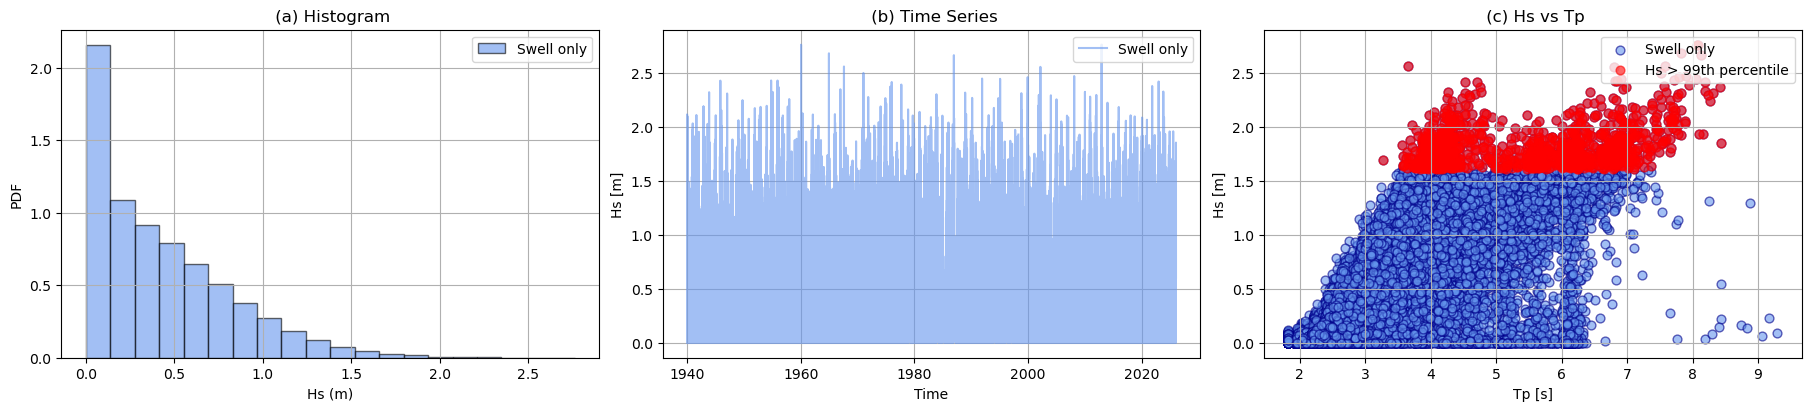

In [6]:


fig, ax = plt.subplots(1, 3, figsize=(18, 4), layout='constrained')
ax[0].set_xlabel('Hs (m)')
ax[0].set_ylabel('PDF')
ax[0].hist(wave_data_wind['Hs'], bins=20, color='cornflowerblue', edgecolor='black', alpha=0.6, histtype='bar', density=True, label= 'Swell only')
ax[0].grid()
ax[0].set_title(' (a) Histogram')
ax[0].legend(loc='upper right');

ax[1].plot(wave_data_wind['time'], wave_data_wind['Hs'], alpha=0.6, color='cornflowerblue',label= 'Swell only')
ax[1].set_title(' (b) Time Series')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Hs [m]')
ax[1].legend(loc='upper right')
ax[1].grid();

ax[2].scatter(wave_data_wind['Tp'], wave_data_wind['Hs'], s=40, color='cornflowerblue', alpha=0.6, edgecolors='darkblue', label= 'Swell only')
ax[2].scatter(Hs_99_df['Tp'], Hs_99_df['Hs'], s=40, color='red', alpha=0.6, label='Hs > 99th percentile')
#ax[2].axhline(y=threshold, color='k', linestyle='--', label=f'th={threshold:.3f}m')
ax[2].set_xlabel('Tp [s]')
ax[2].set_ylabel('Hs [m]')
ax[2].legend(loc='upper right')
ax[2].set_title(' (c) Hs vs Tp')
ax[2].grid();

#print('Average Tp for Hs > 99th percentile:', round(Hs_99['Tp'].mean(), 2), 's')

In [7]:
def pot_method(data, threshold, dtime):
    idx_pot, _ = find_peaks(data, height = threshold, distance = dtime)
    pot_list = data.loc[idx_pot]
    return idx_pot, pot_list

In [8]:
#threshold = Hs_99
Hs_99 = wave_data_wind['Hs'].quantile(0.99)

In [9]:
threshold = Hs_99
dtime = 12 # 72 hours
tare = threshold

indices, pot_maxima = pot_method(wave_data_wind['Hs'], threshold, dtime)

kmax = len(pot_maxima)

print("Number of peaks based on Threshold: ",threshold," and time ",dtime," is ",kmax)
print('Last part of the calculated Peaks over Threshold values: ')
print(pot_maxima.tail())

Number of peaks based on Threshold:  1.6135254  and time  12  is  541
Last part of the calculated Peaks over Threshold values: 
124483   1.62793
124924   1.95996
125245    1.6792
125464   1.63354
125632   1.85522
Name: Hs, dtype: float64


In [10]:
peaks, _ = find_peaks(wave_data_wind['Hs'], height=threshold, distance=dtime)
print('Using POT, the number of maxima obtained is:', peaks.shape[0])

Using POT, the number of maxima obtained is: 541


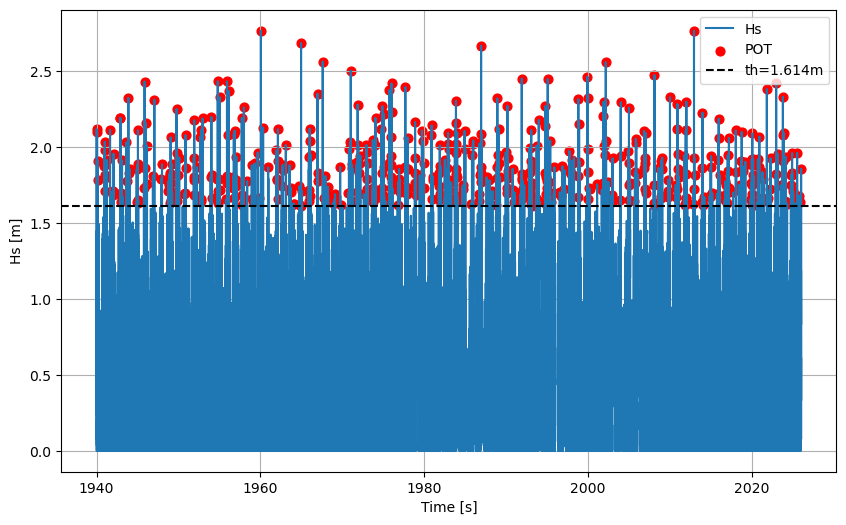

In [11]:
plt.figure(figsize=(10,6))
plt.plot(wave_data_wind['time'],wave_data_wind['Hs'], label='Hs')
plt.scatter(wave_data_wind.iloc[peaks,0], wave_data_wind.iloc[peaks,1], 40,'r', label='POT')
plt.axhline(y=threshold, color='k', linestyle='--', label=f'th={threshold:.3f}m')
plt.xlabel('Time [s]')
plt.ylabel('Hs [m]')
plt.grid()
plt.legend();

In [12]:
# function for ECDF
def ecdf(var):
    x = np.sort(var) # sort the values from small to large
    n = x.size # determine the number of datapoints\
    y = np.arange(1, n+1) / (n+1)
    return [y, x]


In [13]:
# Fit GPD to Hs
params_POT = stats.genpareto.fit(wave_data_wind.iloc[peaks,1]-threshold, floc = 0)
print('The parameters of the fitted distribution are:', *params_POT)

# #Plot in logscale
# x_range = np.linspace(0, 3, 500)
# plt.figure(figsize=(10, 6))
# plt.step(ecdf(wave_data_wind.iloc[peaks, 1])[1], 1-ecdf(wave_data_wind.iloc[peaks, 1])[0],'cornflowerblue', label = 'POT maxima')
# plt.plot(x_range+threshold, 1-stats.genpareto.cdf(x_range, *params_POT),
#              '--k', label='GPD')

# plt.xlabel('Hs (m)')
# plt.ylabel('Exceedence Probability Pr(X > x)')
# #plt.yscale('log') 
# plt.grid()
# plt.legend();

The parameters of the fitted distribution are: -0.1731515265506623 0 0.29397154832736805


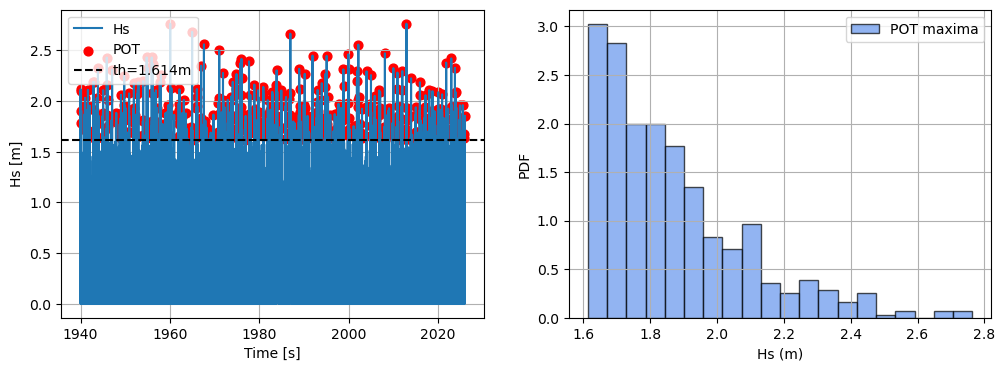

In [14]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(wave_data_wind['time'],wave_data_wind['Hs'], label='Hs')
ax[0].scatter(wave_data_wind.iloc[peaks,0], wave_data_wind.iloc[peaks,1], 40,'r', label='POT')
ax[0].axhline(y=threshold, color='k', linestyle='--', label=f'th={threshold:.3f}m')
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('Hs [m]')
ax[0].grid()
ax[0].legend()

# pdf of POT maxima
#ax[1].step(ecdf(wave_data_wind.iloc[peaks, 1])[1], 1 - ecdf(wave_data_wind.iloc[peaks, 1])[0], 'cornflowerblue', label='POT maxima')
ax[1].hist(wave_data_wind.iloc[peaks, 1], bins=20, density=True, color='cornflowerblue', edgecolor='black', alpha=0.7, label='POT maxima')
ax[1].set_xlabel('Hs (m)')
ax[1].set_ylabel('PDF')
ax[1].grid()
ax[1].legend()
# plt.plot(wave_data_wind['time'],wave_data_wind['Hs'], label='Hs')
# plt.scatter(wave_data_wind.iloc[peaks,0], wave_data_wind.iloc[peaks,1], 40,'r', label='POT')
# plt.axhline(y=threshold, color='k', linestyle='--', label=f'th={threshold:.3f}m')
# plt.xlabel('Time [s]')
# plt.ylabel('Hs [m]')
# plt.grid()
# plt.legend();

# # pdf of POT maxima
# subplot(1,2,2)
# plt.step(ecdf(wave_data_wind.iloc[peaks, 1])[1], 1 - ecdf(wave_data_wind.iloc[peaks, 1])[0], 'cornflowerblue', label='POT maxima')
# plt.hist(wave_data_wind.iloc[peaks, 1], bins=20, density=True, color='cornflowerblue', edgecolor='black', alpha=0.7, label='POT maxima')
# plt.xlabel('Hs (m)')
# plt.ylabel('Exceedence Probability Pr(X > x)')
# plt.grid()
# plt.legend(); 

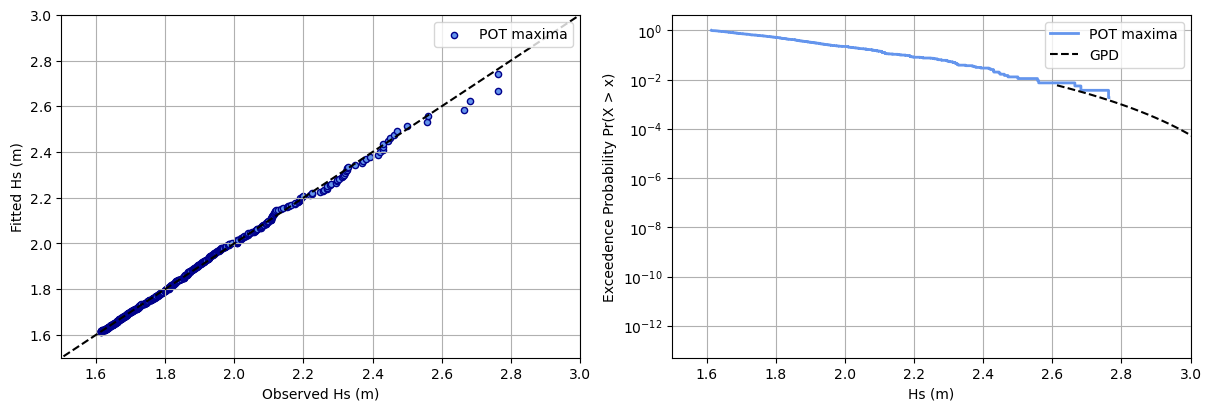

In [15]:
# QQ plot
from math import ceil, trunc
x_min = trunc(min(wave_data_wind.iloc[peaks, 1]))
x_max = ceil(max(wave_data_wind.iloc[peaks, 1]))
x_range = np.linspace(x_min, x_max, 100)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

ax[0].plot([x_min, x_max], [x_min, x_max], '--k')
ax[0].scatter(ecdf(wave_data_wind.iloc[peaks, 1])[1], stats.genpareto.ppf(ecdf(wave_data_wind.iloc[peaks, 1])[0], *params_POT)+threshold, color='cornflowerblue', s=20, edgecolors='darkblue', label='POT maxima')
ax[0].set_xlim(1.5, 3)
ax[0].set_ylim(1.5, 3)
ax[0].set_xlabel('Observed Hs (m)')
ax[0].set_ylabel('Fitted Hs (m)')
#ax[0].set_yscale('log')
#ax[0].set_xscale('log')
#ax[0].set_title('QQ Plot')
ax[0].legend(loc='upper right')
ax[0].grid()

#Plot in logscale
ax[1].step(ecdf(wave_data_wind.iloc[peaks, 1])[1], 1-ecdf(wave_data_wind.iloc[peaks, 1])[0],'cornflowerblue', linewidth=2, label = 'POT maxima')
ax[1].plot(x_range+threshold, 1-stats.genpareto.cdf(x_range, *params_POT),
             '--k', label='GPD')
ax[1].set_xlabel('Hs (m)')
ax[1].set_ylabel('Exceedence Probability Pr(X > x)')
#ax[1].set_title('Log-Scale Plot')
ax[1].set_yscale('log')
ax[1].set_xlim(1.5, 3.0)
ax[1].legend(loc='upper right')
ax[1].grid();



## KS test

In [16]:
excesses = wave_data_wind.iloc[peaks, 1] - threshold

In [17]:
# KS test on excesses (what the GPD was actually fitted to)
_, p_Hs = stats.kstest(excesses, stats.genpareto.cdf, args=params_POT)
print('KS test p-value for fitted distribution to Hs:', round(p_Hs, 9))


KS test p-value for fitted distribution to Hs: 0.977409294


In [18]:
# not needed
loc_exp, lambda_exp = stats.expon.fit(excesses, floc=0)
print('The parameters of the fitted exponential distribution are:', loc_exp, lambda_exp)

The parameters of the fitted exponential distribution are: 0.0 0.2505670194085027


## MAKE SURE DIVIDED BY CORRECT NR OF YEARS I.E. 85

In [19]:
#POT
average_n_excesses = len(wave_data_wind.iloc[peaks, 1])/85 #number of sampled extremes divided by the number of years
non_exc_prob = 1- 1/(1000*average_n_excesses)
POT_design_value = stats.genpareto.ppf(non_exc_prob, *params_POT)+threshold
EXP1000 = stats.expon.ppf(non_exc_prob, loc_exp, lambda_exp) + threshold
print(non_exc_prob)
print('The design value for a RT = 1000 years computed using POT is:', np.round(POT_design_value, 3), 'm')
#print('the Hs,1000 value using exponential is', np.round(EXP1000, 3), 'm')

0.9998428835489833
The design value for a RT = 1000 years computed using POT is: 2.939 m


In [20]:
# POT
RT_FLS = 50  # return period in years

# Average number of exceedances per year
average_n_excesses = len(wave_data_wind.iloc[peaks, 1]) / 85

# Non-exceedance probability
non_exc_prob = 1 - 1 / (RT_FLS * average_n_excesses)

# Significant wave height for RT = 50 years
Hs_50 = stats.genpareto.ppf(non_exc_prob, *params_POT) + threshold

print('Non-exceedance probability:', np.round(non_exc_prob, 6))
print('The design value for RT = 50 years computed using POT is:',
      np.round(Hs_50, 3), 'm')

Non-exceedance probability: 0.996858
The design value for RT = 50 years computed using POT is: 2.685 m


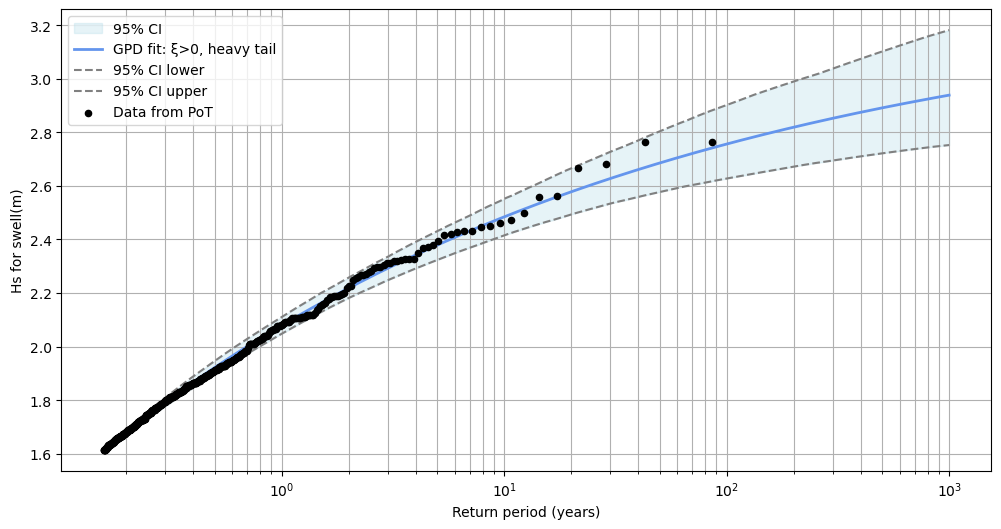

The design value for a RT = 1000 years computed using POT is: 2.939 m
95% bootstrap CI: [ 2.752 , 3.181 ] m


In [21]:
#range of RT
RT_range = np.logspace(-1, 3, 1000)

#POT&GPD for Hs
average_n_excesses = len(wave_data_wind.iloc[peaks, 1])/85 #number of sampled extremes divided by the number of years
non_exc_prob_range = 1- 1/(RT_range*average_n_excesses)
non_exc_prob_1000 = 1- 1/(1000*average_n_excesses)
POT_range = stats.genpareto.ppf(non_exc_prob_range, *params_POT)+threshold

# -----------------------------
# Bootstrap 95% confidence interval
# -----------------------------
excesses = wave_data_wind.iloc[peaks, 1].values - threshold

n_boot = 1000
POT_boot = np.zeros((n_boot, len(RT_range)))
POT_1000_boot = np.zeros(n_boot)
POT_1000 = stats.genpareto.ppf(non_exc_prob_1000, *params_POT)+threshold

rng = np.random.default_rng(42)

for i in range(n_boot):
    boot_excesses = rng.choice(excesses, size=len(excesses), replace=True)

    # refit GPD to bootstrap sample, keeping loc = 0
    boot_params = stats.genpareto.fit(boot_excesses, floc=0)

    # full return-period curve
    POT_boot[i, :] = (
        stats.genpareto.ppf(non_exc_prob_range, *boot_params)
        + threshold
    )

    # 1,000-year value
    POT_1000_boot[i] = (
        stats.genpareto.ppf(non_exc_prob_1000, *boot_params)
        + threshold
    )

# CI bounds
POT_lower = np.percentile(POT_boot, 2.5, axis=0)
POT_upper = np.percentile(POT_boot, 97.5, axis=0)

POT_1000_lower = np.percentile(POT_1000_boot, 2.5)
POT_1000_upper = np.percentile(POT_1000_boot, 97.5)

# Empirical return periods for the POT data points
n_years = len(wave_data_wind) / (4 * 365.25)  # total years (4 obs/day)
n_peaks = len(peaks)
sorted_Hs = np.sort(wave_data_wind.iloc[peaks, 1].values)
emp_RT = n_years / (n_peaks * (1 - np.arange(1, n_peaks + 1) / (n_peaks + 1)))

plt.figure(figsize=(12, 6))

# Shaded CI band
plt.fill_between(
    RT_range,
    POT_lower,
    POT_upper,
    color='lightblue',
    alpha=0.3,
    label='95% CI'
)

# GPD fit
plt.plot(RT_range, POT_range, 'cornflowerblue', linewidth=2, label='GPD fit: ξ>0, heavy tail')

# # Exponential fit
# plt.plot(RT_range, EXP_range, '--', color='orange', linewidth=2, label='Exponential fit')

plt.plot(RT_range, POT_lower, '--', color='gray', label='95% CI lower')
plt.plot(RT_range, POT_upper, '--', color='gray', label='95% CI upper')

# Empirical data points
plt.scatter(emp_RT, sorted_Hs, s=20, color='black', zorder=5, label='Data from PoT')

plt.xlabel('Return period (years)')
plt.ylabel('Hs for swell(m)')
plt.xscale('log')
plt.grid(True, which='both')
plt.legend()
plt.show()

print(
    'The design value for a RT = 1000 years computed using POT is:',
    np.round(POT_1000, 3),
    'm'
)


print(
    '95% bootstrap CI:',
    '[',
    np.round(POT_1000_lower, 3),
    ',',
    np.round(POT_1000_upper, 3),
    '] m'
)

Average Tp for Hs swell > 99th percentile: 5.49 s


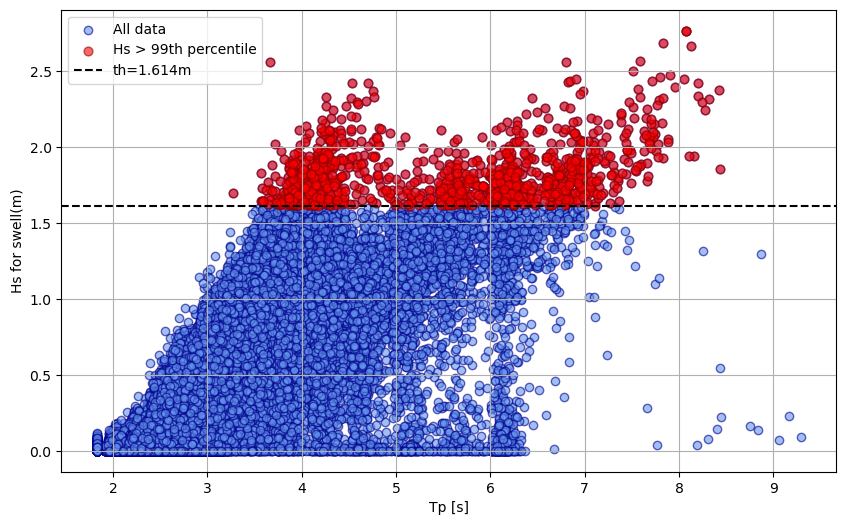

In [22]:
plt.scatter(wave_data_wind['Tp'], wave_data_wind['Hs'], alpha=0.6, color='cornflowerblue', edgecolors='darkblue', label='All data')
plt.scatter(Hs_99_df['Tp'], Hs_99_df['Hs'], 40,'r', edgecolors='darkred', alpha=0.6, label='Hs > 99th percentile')
plt.axhline(y=threshold, color='k', linestyle='--', label=f'th={threshold:.3f}m')
plt.xlabel('Tp [s]')
plt.ylabel('Hs for swell(m)')
plt.legend()
plt.grid()
print('Average Tp for Hs swell > 99th percentile:', round(Hs_99_df['Tp'].mean(), 2), 's')

C:\Users\arthu\AppData\Local\Temp\ipykernel_11952\825907729.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend();


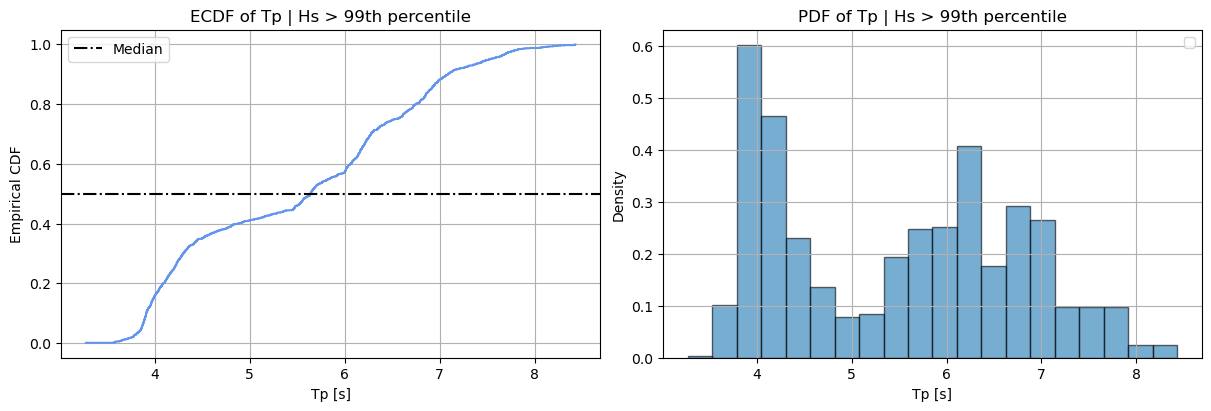

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

ecdf_Tp_Hs99 = ecdf(Hs_99_df['Tp'])
Tp_Hs99 = Hs_99_df['Tp'].values
# ECDF
ax[0].step(ecdf_Tp_Hs99[1], ecdf_Tp_Hs99[0], where='post', color='cornflowerblue')
ax[0].set_xlabel('Tp [s]')
ax[0].axhline(0.5, color='k', linestyle='-.', label='Median')
ax[0].set_ylabel('Empirical CDF')
ax[0].set_title('ECDF of Tp | Hs > 99th percentile')
ax[0].grid()
ax[0].legend()

# PDF
ax[1].hist(Tp_Hs99, bins=20, density=True, alpha=0.6, edgecolor='k')
ax[1].set_xlabel('Tp [s]')
ax[1].set_ylabel('Density')
ax[1].set_title('PDF of Tp | Hs > 99th percentile')
ax[1].grid()
ax[1].legend();

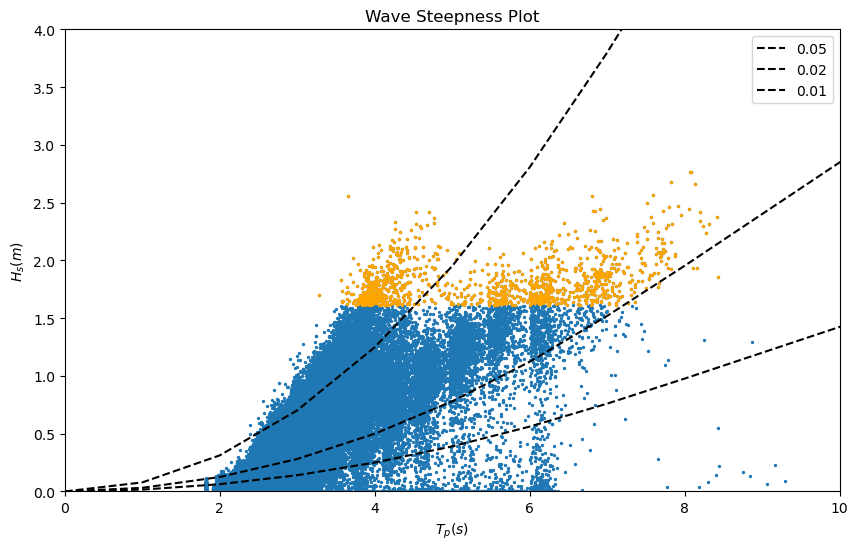

In [24]:
#Calculate theoretical wave steepness lines following the wave dispersion relationship.
N = 15
iterations = 20
Depth = 35
T_p = np.linspace(0,N,N+1)
L0 = 9.81*(T_p**2)/(2*np.pi) # Deep water wave length
L = np.zeros((iterations,len(T_p)))
L[0,:] = L0                # Initial guess for wave length = deep water wave length
L[0,0] = 0.1

# Calculate the wave periods using an iterative approach
for iL in np.arange(1,(len(L[:,0]))):
    for jL in np.arange(0,len(T_p)):
        L[iL,jL] =  L0[jL]*np.tanh(2*np.pi*(Depth/(L[iL-1,jL])))

# Compute theoretical significant wave heights for different steepnesses
Hs005 = L[-1,:]*0.05;
Hs002 = L[-1,:]*0.02;
Hs001 = L[-1,:]*0.01;

#plt.figure(3, figsize = (10,6), facecolor='white')
plt.scatter(wave_data_wind['Tp'], wave_data_wind['Hs'], s = 2)
plt.scatter(Hs_99_df['Tp'], Hs_99_df['Hs'], color='orange', s = 2)
plt.plot(T_p[:-2], Hs005[:-2], linestyle = 'dashed', color = 'black', label = 0.05)
plt.plot(T_p[:-2], Hs002[:-2], linestyle = 'dashed', color = 'black', label = 0.02)
plt.plot(T_p[:-2], Hs001[:-2], linestyle = 'dashed', color = 'black', label = 0.01)
plt.xlim(0, 10)
plt.ylim(0,4)
plt.xlabel('${T_{p} (s)}$')
plt.ylabel('${H_s (m)}$')
plt.title('Wave Steepness Plot')
plt.legend()

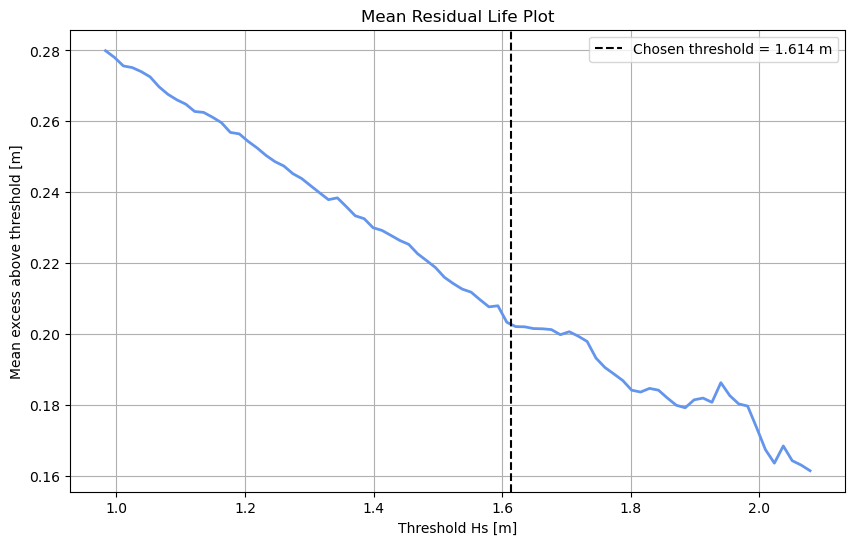

In [25]:
# -----------------------------
# Mean Residual Life plot
# -----------------------------

def mean_residual_life(data, thresholds):
    mean_excesses = []
    n_exceedances = []

    for th in thresholds:
        excesses_th = data[data > th].values - th  # all exceedances, no declustering

        if len(excesses_th) > 1:
            mean_excesses.append(np.mean(excesses_th))
            n_exceedances.append(len(excesses_th))
        else:
            mean_excesses.append(np.nan)
            n_exceedances.append(len(excesses_th))

    return np.array(mean_excesses), np.array(n_exceedances)


# threshold range to test
threshold_range = np.linspace(
    wave_data_wind['Hs'].quantile(0.90),
    wave_data_wind['Hs'].quantile(0.999),
    80
)

mean_excesses, n_exceedances = mean_residual_life(
    wave_data_wind['Hs'],
    threshold_range
)

# plot MRL
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(threshold_range, mean_excesses, color='cornflowerblue', linewidth=2)
ax1.axvline(threshold, color='k', linestyle='--', label=f'Chosen threshold = {threshold:.3f} m')

ax1.set_xlabel('Threshold Hs [m]')
ax1.set_ylabel('Mean excess above threshold [m]')
ax1.set_title('Mean Residual Life Plot')
ax1.grid()
ax1.legend(loc='upper right')

plt.show()

In [26]:
# -----------------------------
# GPD Parameter Stability method
# -----------------------------

threshold_range = np.linspace(
    wave_data_wind['Hs'].quantile(0.90),
    wave_data_wind['Hs'].quantile(0.999),
    80
)

shape_xi = []
scale_sigma = []
modified_scale = []
n_peaks = []

for th in threshold_range:
    excesses_th = wave_data_wind['Hs'][wave_data_wind['Hs'] > th].values - th
    n_peaks.append(len(excesses_th))

    if len(excesses_th) > 10:
        xi, loc, sigma = stats.genpareto.fit(excesses_th, floc=0)
        shape_xi.append(xi)
        scale_sigma.append(sigma)
        modified_scale.append(sigma - xi * th)
    else:
        shape_xi.append(np.nan)
        scale_sigma.append(np.nan)
        modified_scale.append(np.nan)

shape_xi = np.array(shape_xi)
scale_sigma = np.array(scale_sigma)
modified_scale = np.array(modified_scale)
n_peaks = np.array(n_peaks)

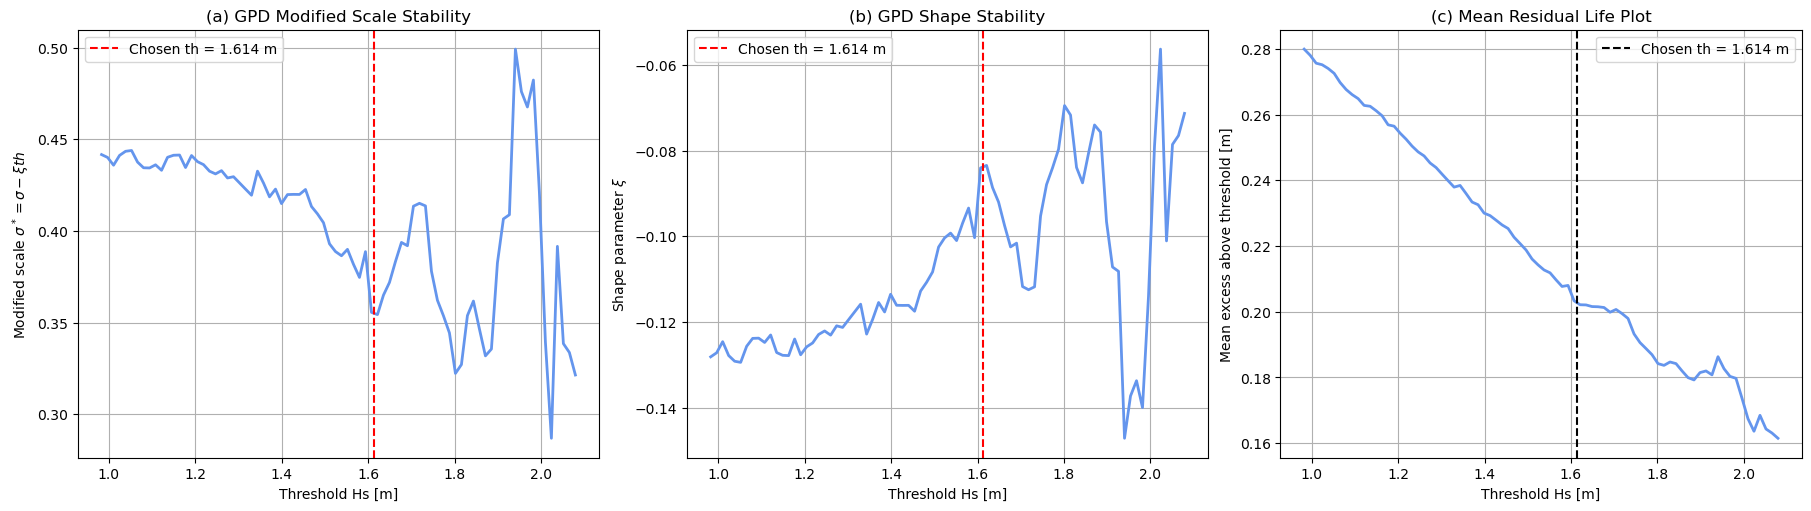

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5), layout='constrained')

# (a) Modified scale stability
ax[0].plot(threshold_range, modified_scale, color='cornflowerblue', linewidth=2)
ax[0].axvline(threshold, color='red', linestyle='--', label=f'Chosen th = {threshold:.3f} m')
ax[0].set_xlabel('Threshold Hs [m]')
ax[0].set_ylabel(r'Modified scale $\sigma^* = \sigma - \xi th$')
ax[0].set_title('(a) GPD Modified Scale Stability')
ax[0].grid()
ax[0].legend()

# (b) Shape stability
ax[1].plot(threshold_range, shape_xi, color='cornflowerblue', linewidth=2)
ax[1].axvline(threshold, color='red', linestyle='--', label=f'Chosen th = {threshold:.3f} m')
ax[1].set_xlabel('Threshold Hs [m]')
ax[1].set_ylabel(r'Shape parameter $\xi$')
ax[1].set_title('(b) GPD Shape Stability')
ax[1].grid()
ax[1].legend()

# (c) Mean Residual Life
mean_excesses, n_exceedances = mean_residual_life(wave_data_wind['Hs'], threshold_range)
ax[2].plot(threshold_range, mean_excesses, color='cornflowerblue', linewidth=2)
ax[2].axvline(threshold, color='k', linestyle='--', label=f'Chosen th = {threshold:.3f} m')
ax[2].set_xlabel('Threshold Hs [m]')
ax[2].set_ylabel('Mean excess above threshold [m]')
ax[2].set_title('(c) Mean Residual Life Plot')
ax[2].grid()
ax[2].legend()

plt.show()

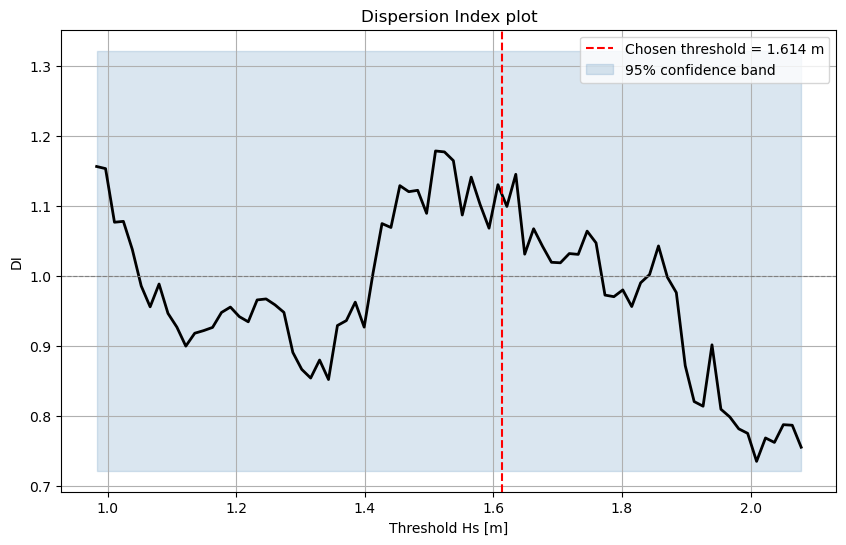

In [28]:
# -----------------------------
# Dispersion Index plot
# -----------------------------

def dispersion_index_plot(data, time_years, thresholds, dtime, significance=0.05):
    """
    Dispersion Index (DI) plot for threshold and declustering time selection.
    
    DI = variance(N_k) / mean(N_k), where N_k is the number of POT peaks per year k.
    Under a Poisson process, DI should be ~1.
    Confidence band based on chi-squared test at given significance level.

    Parameters
    ----------
    data        : pd.Series  – Hs time series
    time_years  : pd.Series  – fractional year for each observation
    thresholds  : array-like – threshold values to test
    dtime       : int        – minimum distance between peaks (in samples)
    significance: float      – significance level for chi-squared CI (default 0.05)
    """
    years = np.unique(np.floor(time_years).astype(int))
    n_years = len(years)

    DI_values = []

    for th in thresholds:
        peaks_th, _ = find_peaks(data.values, height=th, distance=dtime)

        # Count how many POT peaks fall in each year
        peak_years = np.floor(time_years.iloc[peaks_th]).astype(int)
        counts_per_year = np.array([np.sum(peak_years == y) for y in years])

        mean_count = np.mean(counts_per_year)

        if mean_count > 0:
            DI = np.var(counts_per_year, ddof=1) / mean_count
        else:
            DI = np.nan

        DI_values.append(DI)

    DI_values = np.array(DI_values)

    # Chi-squared confidence band:
    # Under H0 (Poisson), (n_years - 1) * DI ~ chi2(n_years - 1)
    # So DI is within [chi2_low, chi2_high] / (n_years - 1)
    dof = n_years - 1
    chi2_low  = stats.chi2.ppf(significance / 2, df=dof) / dof
    chi2_high = stats.chi2.ppf(1 - significance / 2, df=dof) / dof

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(thresholds, DI_values, color='black', linewidth=2)
    ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(threshold, color='red', linestyle='--', label=f'Chosen threshold = {threshold:.3f} m')
    ax.fill_between(thresholds, chi2_low, chi2_high,
                    color='steelblue', alpha=0.2,
                    label=f'{int((1-significance)*100)}% confidence band')

    ax.set_xlabel('Threshold Hs [m]')
    ax.set_ylabel('DI')
    ax.set_title('Dispersion Index plot')
    ax.legend(loc='upper right')
    ax.grid()
    plt.show()

    return DI_values


# Run it — same threshold_range as MRL and parameter stability
threshold_range = np.linspace(
    wave_data_wind['Hs'].quantile(0.90),
    wave_data_wind['Hs'].quantile(0.999),
    80
)

DI_values = dispersion_index_plot(
    data        = wave_data_wind['Hs'],
    time_years  = wave_data_wind['time'],
    thresholds  = threshold_range,
    dtime       = dtime,
    significance= 0.05
)

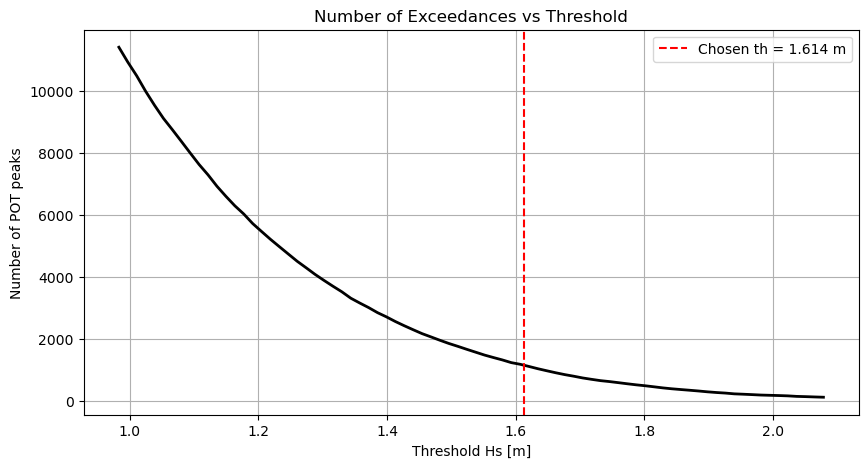

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(threshold_range, n_peaks, color='black', linewidth=2)
plt.axvline(threshold, color='red', linestyle='--', label=f'Chosen th = {threshold:.3f} m')

plt.xlabel('Threshold Hs [m]')
plt.ylabel('Number of POT peaks')
plt.title('Number of Exceedances vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [30]:
print('Selected threshold:', round(threshold, 3), 'm')
print('Selected number of POT peaks:', len(peaks))

xi_sel, loc_sel, sigma_sel = stats.genpareto.fit(
    wave_data_wind.iloc[peaks]['Hs'].values - threshold,
    floc=0
)

sigma_star_sel = sigma_sel - xi_sel * threshold

print('Selected xi:', round(xi_sel, 4))
print('Selected sigma:', round(sigma_sel, 4))
print('Selected modified scale sigma*:', round(sigma_star_sel, 4))

Selected threshold: 1.614 m
Selected number of POT peaks: 541
Selected xi: -0.1732
Selected sigma: 0.294
Selected modified scale sigma*: 0.5734
